In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("mail_data.csv")

In [3]:
df.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### Process 1 - Label Encoding
##### Machine learning models work with numerical values. So, the text labels i.e. ham and spam are converted into numerical form.

In [6]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [7]:
df['Category'] = encoder.fit_transform(df['Category'])

In [8]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Process 2 - Data Cleaning
##### In this step, the dataset is checked for missing values and duplicate messages. Duplicate data is removed to make the model training more accurate.

In [9]:
df.isnull().sum() #checking missing values

Category    0
Message     0
dtype: int64

In [10]:
df.duplicated().sum() #checking duplicate values

np.int64(415)

In [11]:
df = df.drop_duplicates(keep = 'first')

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(5157, 2)

In [14]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Process 3 - Exploratory Data Analysis (EDA)
##### Here, analyzing how many messages are spam and how many are ham to understand the data distribution.

In [15]:
df['Category'].value_counts()

Category
0    4516
1     641
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x11d754d40>,
 [Text(-1.0171946362150524, 0.41870642705280725, 'ham'),
  Text(1.0171945729921292, -0.4187065806449194, 'spam')],
 [Text(-0.554833437935483, 0.22838532384698573, '87.57'),
  Text(0.5548334034502522, -0.22838540762450146, '12.43')])

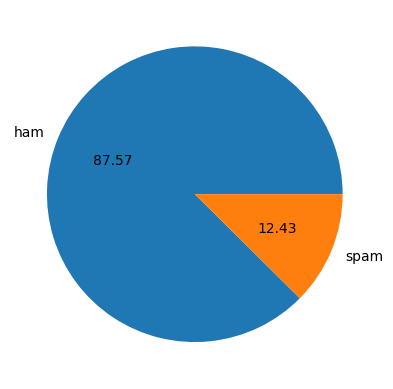

In [16]:
import matplotlib.pyplot as plt
plt.pie(df['Category'].value_counts(), labels=['ham', 'spam'], autopct = "%0.2f")

In [17]:
#Data is imbalanced

In [18]:
# Number of characters in each message
df.loc[:, 'num_characters'] = df['Message'].apply(len)

# Number of words
df.loc[:, 'num_words'] = df['Message'].apply(lambda x: len(x.split()))

# Number of sentences
df.loc[:, 'num_sentences'] = df['Message'].apply(
    lambda x: x.count('.') + x.count('!') + x.count('?')
)

In [19]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,79.103936,15.410704,2.489044
std,58.382922,11.118902,2.721229
min,2.000000,1.000000,0.000000
25%,36.000000,7.000000,1.000000
50%,61.000000,12.000000,2.000000
75%,118.000000,22.000000,3.000000
max,910.000000,171.000000,42.000000


In [20]:
#For ham messages
df[df['Category'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.869353,14.239814,2.416519
std,56.708301,11.179471,2.810813
min,2.000000,1.000000,0.000000
25%,34.000000,7.000000,1.000000
50%,53.000000,11.000000,2.000000
75%,91.000000,19.000000,3.000000
max,910.000000,171.000000,42.000000


In [21]:
#For spam messages
df[df['Category'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,641.000000,641.000000,641.000000
mean,137.118565,23.659906,3.000000
std,30.399707,6.038659,1.903122
min,7.000000,1.000000,0.000000
25%,130.000000,21.000000,2.000000
50%,148.000000,25.000000,3.000000
75%,157.000000,28.000000,4.000000
max,223.000000,35.000000,13.000000


In [22]:
df.head()

,Category,Message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,8
1,0,Ok lar... Joking wif u oni...,29,6,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,0,U dun say so early hor... U c already then say...,49,11,6
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0


### plotting it in a histogram graph

In [23]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

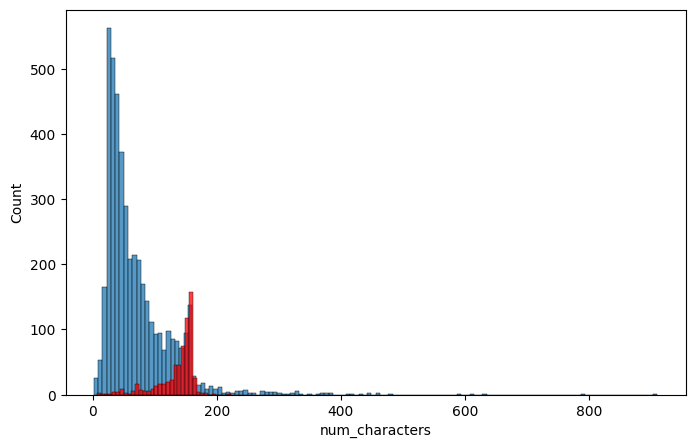

In [24]:
plt.figure(figsize = (8,5))
sns.histplot(df[df['Category'] == 0]['num_characters'])
sns.histplot(df[df['Category'] == 1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

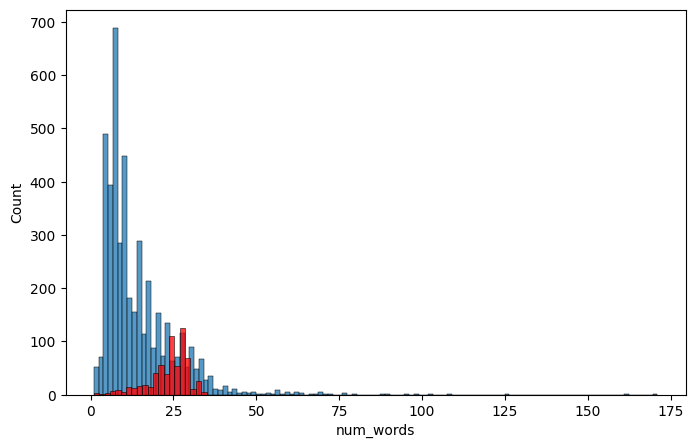

In [25]:
plt.figure(figsize = (8,5))
sns.histplot(df[df['Category'] == 0]['num_words'])
sns.histplot(df[df['Category'] == 1]['num_words'], color='red')

In [26]:
df.corr(numeric_only=True)

,Category,num_characters,num_words,num_sentences
Category,1.000000,0.374409,0.279540,0.070748
num_characters,0.374409,1.000000,0.973985,0.495756
num_words,0.279540,0.973985,1.000000,0.478690
num_sentences,0.070748,0.495756,0.478690,1.000000


### Process 4 - Text Preprocessing
##### converting text to lowercase, removing stopwords, and applying stemming to reduce words to their root form.

In [27]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

In [28]:
stop_words = set(stopwords.words("english"))

for w in ["not", "no", "nor", "never"]:
    stop_words.discard(w)

lemmatizer = WordNetLemmatizer()

In [29]:
def transform_text(message):
    message = message.lower()

    message = re.sub(r"http\S+|www\S+", " url ", message)
    message = re.sub(r"\S+@\S+", " email ", message)

    # Tokenize
    tokens = nltk.word_tokenize(message)

    y = []
    for word in tokens:
        if word.isalnum():
            if word.isdigit():
                y.append("num")
            else:
                y.append(word)

    # Remove stopwords
    y = [word for word in y if word not in stop_words]

    # LEMMATIZATION
    y = [lemmatizer.lemmatize(word) for word in y]

    return " ".join(y)

In [30]:
transform_text('Hello, I am Subin Dulal.')

'hello subin dulal'

In [31]:
df['transformed_text'] = df['Message'].apply(transform_text)

In [32]:
df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,8,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,6,6,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,free entry num wkly comp win fa cup final tkts...
3,0,U dun say so early hor... U c already then say...,49,11,6,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,nah think go usf life around though


In [33]:
from wordcloud import WordCloud

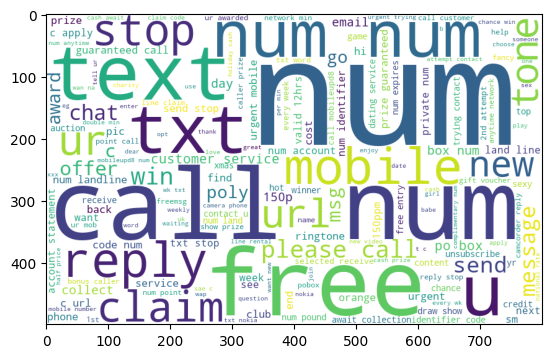

In [34]:
#Wordcloud for spam
wc = WordCloud(width=800, height=500, min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['Category'] ==1] ['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

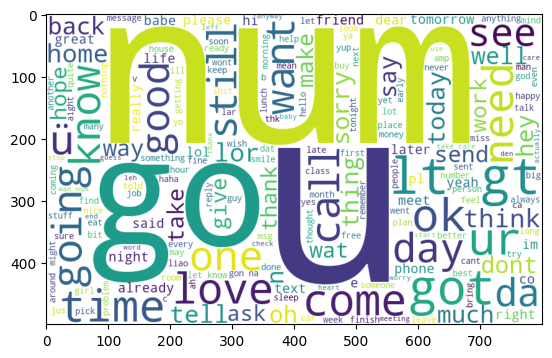

In [35]:
#Wordcloud for ham
wc = WordCloud(width=800, height=500, min_font_size=10,background_color='white')
ham_wc = wc.generate(df[df['Category'] == 0] ['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [36]:
df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,8,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,6,6,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,free entry num wkly comp win fa cup final tkts...
3,0,U dun say so early hor... U c already then say...,49,11,6,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,nah think go usf life around though


### Process 5 - Text Vectorization (TF-IDF)
##### converting text data into numerical vectors.

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [38]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [39]:
X.shape

(5157, 5000)

In [40]:
y = df['Category'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5157,))

### Process 6: Train-Test Split
##### Dividing dataset into training and testing sets. Training set to train the model, while the testing set to evaluate its performance.

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

### Process 7: Model Training using Naive Bayes

In [43]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results = []

In [44]:
# 1) Create model
mnb = MultinomialNB(alpha=0.5)

In [45]:
# 2) Train model
mnb.fit(X_train, y_train)

,alpha,0.5
,force_alpha,True
,fit_prior,True
,class_prior,None


In [46]:
# 3) Predict on test data
y_pred_nb = mnb.predict(X_test)

In [47]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

In [48]:
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Accuracy : 0.9825581395348837
Precision: 1.0
Recall   : 0.859375
F1 Score : 0.9243697478991597


In [49]:
results.append(["Naive Bayes", nb_accuracy, nb_precision, nb_recall, nb_f1])

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

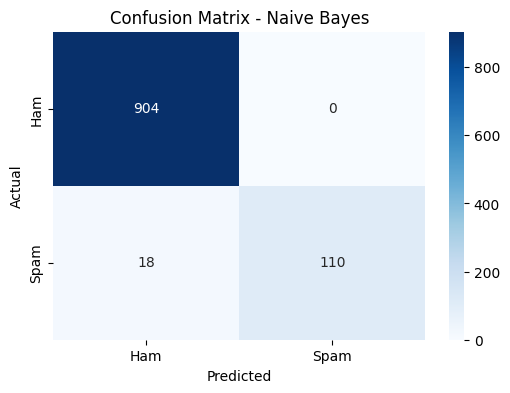

In [51]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

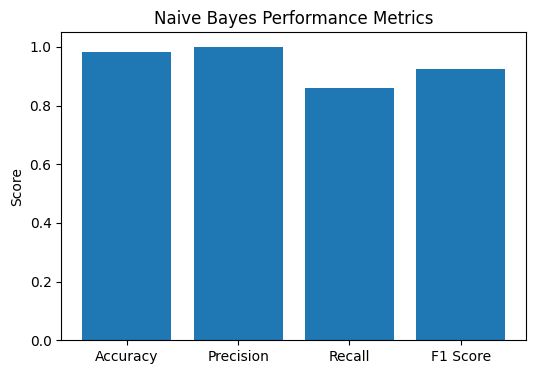

In [52]:
plt.figure(figsize=(6,4))
plt.bar(
    ["Accuracy", "Precision", "Recall", "F1 Score"],
    [nb_accuracy, nb_precision, nb_recall, nb_f1]
)
plt.ylim(0, 1.05)
plt.title("Naive Bayes Performance Metrics")
plt.ylabel("Score")
plt.show()

###  Process 8: Model Training using Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")

In [55]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [56]:
y_pred_lr = lr.predict(X_test)

In [57]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

In [58]:
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.9738372093023255
Precision: 0.8796992481203008
Recall   : 0.9140625
F1 Score : 0.896551724137931


In [59]:
results.append(["Logistic Regression", lr_accuracy, lr_precision, lr_recall, lr_f1])

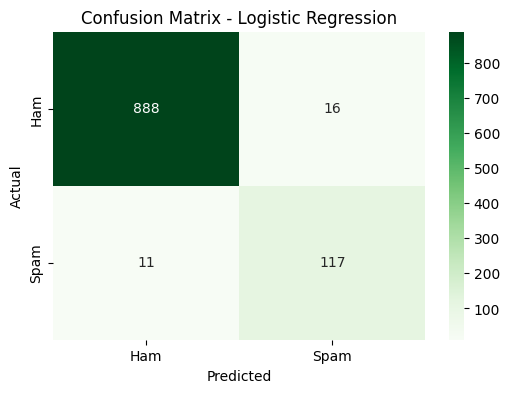

In [60]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

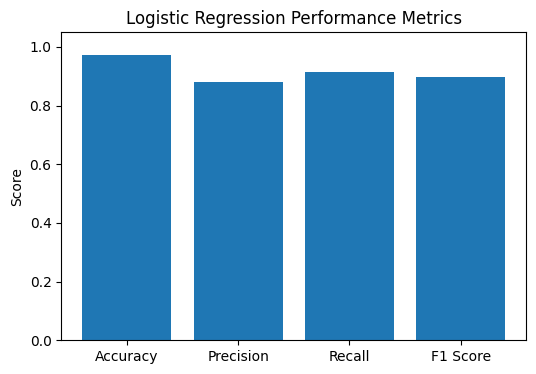

In [61]:
plt.figure(figsize=(6,4))
plt.bar(
    ["Accuracy", "Precision", "Recall", "F1 Score"],
    [lr_accuracy, lr_precision, lr_recall, lr_f1]
)
plt.ylim(0, 1.05)
plt.title("Logistic Regression Performance Metrics")
plt.ylabel("Score")
plt.show()

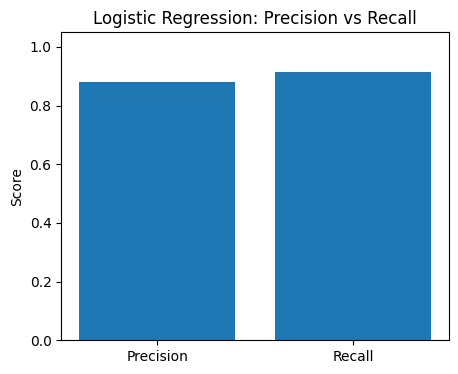

In [62]:
plt.figure(figsize=(5,4))
plt.bar(
    ["Precision", "Recall"],
    [lr_precision, lr_recall]
)
plt.ylim(0, 1.05)
plt.title("Logistic Regression: Precision vs Recall")
plt.ylabel("Score")
plt.show()

In [63]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.982558,1.000000,0.859375,0.924370
1,Logistic Regression,0.973837,0.879699,0.914062,0.896552


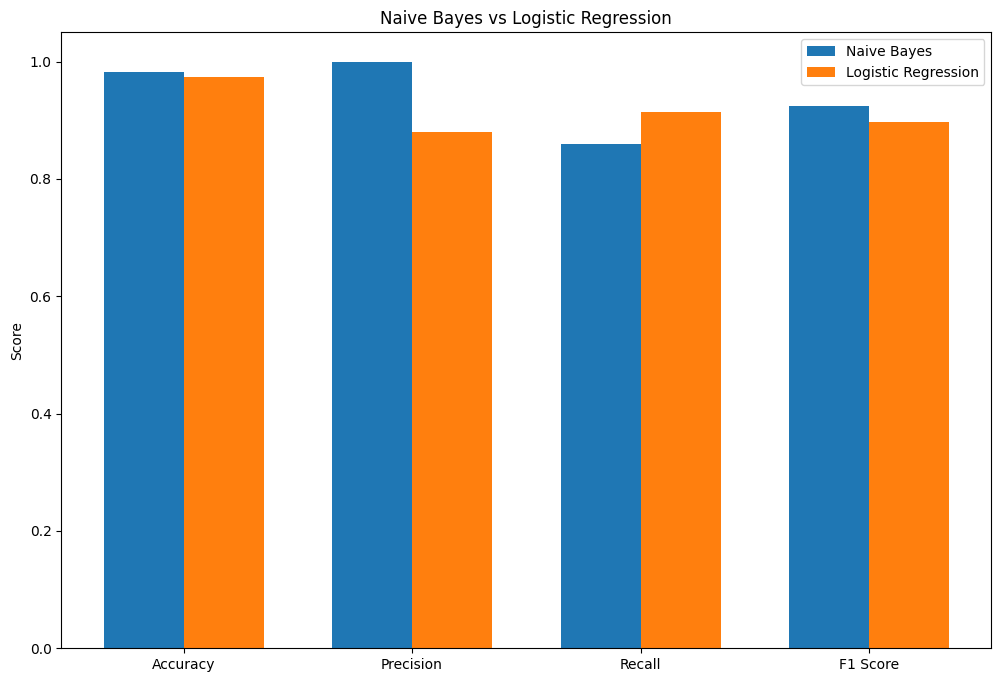

In [64]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

nb_values = results_df[results_df["Model"] == "Naive Bayes"][metrics].values[0]
lr_values = results_df[results_df["Model"] == "Logistic Regression"][metrics].values[0]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12,8))
plt.bar(x - width/2, nb_values, width, label="Naive Bayes")
plt.bar(x + width/2, lr_values, width, label="Logistic Regression")
plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.title("Naive Bayes vs Logistic Regression")
plt.ylabel("Score")
plt.legend()
plt.show()

In [65]:
def predict_label(model, message):
    # preprocessing the message
    text = transform_text(message)
    
    # converting text to numerical form
    vector = tfidf.transform([text]).toarray()
    
    # prediction
    prediction = model.predict(vector)[0]
    return "Spam" if prediction == 1 else "Ham"

In [72]:
def predictions(message):

    result_nb = predict_label(mnb, message)
    result_lr = predict_label(lr, message)

    print(f"Message: {message}")
    print("Prediction Results:")
    print(f"Naive Bayes Prediction        : {result_nb}")
    print(f"Logistic Regression Prediction: {result_lr}")

In [73]:
predictions("Congratulations! You've won a free prize. Click here.")

Message: Congratulations! You've won a free prize. Click here.
Prediction Results:
Naive Bayes Prediction        : Spam
Logistic Regression Prediction: Spam


In [74]:
predictions("Are we still meeting at 5 PM today?")

Message: Are we still meeting at 5 PM today?
Prediction Results:
Naive Bayes Prediction        : Ham
Logistic Regression Prediction: Ham


In [76]:
predictions("Alert: Your bank account has been accessed. Verify now.")

Message: Alert: Your bank account has been accessed. Verify now.
Prediction Results:
Naive Bayes Prediction        : Ham
Logistic Regression Prediction: Ham


In [77]:
predictions("Just finished the assignment. Want to check it?")

Message: Just finished the assignment. Want to check it?
Prediction Results:
Naive Bayes Prediction        : Ham
Logistic Regression Prediction: Ham
